# Futures Backtesting with Contract Specifications

**Docker image**: `ml4t`

This notebook introduces futures-specific backtesting mechanics using the
**ml4t-backtest** engine. Futures contracts differ from equities in several
critical ways that affect P&L calculation, cost modeling, and position sizing.

| Aspect | Equities | Futures |
|--------|----------|---------|
| **P&L Formula** | (exit - entry) × qty | (exit - entry) × qty × **multiplier** |
| **Costs** | % of trade value | **$ per contract** (fixed) |
| **Sessions** | Market hours (9:30–4 ET) | **Overnight sessions** (e.g., 5 PM CT) |
| **Long-Short** | Short selling requires borrowing | **Symmetric** — no borrowing cost |
| **Position Sizing** | Shares × price | Contracts × price × **multiplier** |

**Learning Objectives:**
1. Define `ContractSpec` and understand why multipliers change P&L by 20×–1000×
2. Size positions correctly using notional value (price × multiplier)
3. Implement a long-short momentum strategy (natural for futures)
4. Compare per-contract vs percentage-based costs
5. Analyze sector attribution across diversified asset classes

**Book Reference:** Chapter 16, Sections 16.2-16.3 — trading protocol and
event-driven validation.

**Prerequisites:**
- Ch2 NB 04 ([`04_cme_futures_eda`](../02_financial_data_universe/04_cme_futures_eda.ipynb)): CME data structure, 30 products
- Ch2 NB 05 ([`05_futures_session_aggregation`](../02_financial_data_universe/05_futures_session_aggregation.ipynb)): Session boundaries (4 PM CT)
- Ch2 NB 06 ([`06_futures_continuous`](../02_financial_data_universe/06_futures_continuous.ipynb)): Continuous contract construction
- Ch16 NB 01–03: Backtesting first principles and ml4t-backtest basics

## Setup

In [1]:
"""Futures Backtesting with Contract Specifications — multiplier-aware simulation using ml4t-backtest."""

import warnings
from pathlib import Path

import numpy as np
import plotly.graph_objects as go
import polars as pl
import yaml

warnings.filterwarnings("ignore")

# Data loading
# ml4t-backtest imports
from ml4t.backtest import (
    AssetClass,
    BacktestConfig,
    ContractSpec,
    DataFeed,
    Engine,
    ExecutionMode,
    OrderSide,
    Strategy,
)
from ml4t.backtest.config import CommissionType, SlippageType

from data import load_cme_futures
from utils.paths import REPO_ROOT

In [2]:
# Production defaults — Papermill injects overrides after this cell
START_DATE = "2018-01-01"
END_DATE = "2024-01-01"
INITIAL_CASH = 1_000_000
LOOKBACK = 63  # ~3 months momentum lookback
REBALANCE_EVERY = 21  # ~monthly rebalance (trading days)
LONG_N = 2  # Long top 2 by momentum
SHORT_N = 2  # Short bottom 2 by momentum
RUN_FULL_UNIVERSE = True

In [3]:
# Six demo products — one per sector
PRODUCTS = ["ES", "CL", "GC", "ZN", "6E", "ZC"]

## 1. Load CME Futures Data

We load session-aligned daily bars via `load_cme_futures()`. These bars use
**4 PM CT session boundaries** (not midnight UTC) — see Ch2 NB 05 for the
aggregation methodology that converts hourly Databento bars to daily sessions.

In [4]:
cme_data = load_cme_futures(products=PRODUCTS, tenors=[0], start_date=START_DATE, end_date=END_DATE)

available_products = sorted(cme_data["product"].unique().to_list())
missing_products = [product for product in PRODUCTS if product not in available_products]
if missing_products:
    print(f"Unavailable in current data slice: {missing_products}")
PRODUCTS = [product for product in PRODUCTS if product in available_products]
if len(PRODUCTS) < LONG_N + SHORT_N:
    raise ValueError(
        "Need at least LONG_N + SHORT_N products after filtering for available futures data."
    )

print(f"Loaded {len(cme_data):,} daily bars for {cme_data['product'].n_unique()} products")
print(f"Date range: {cme_data['session_date'].min()} to {cme_data['session_date'].max()}")
print(f"Products: {sorted(cme_data['product'].unique().to_list())}")

Loaded 9,251 daily bars for 6 products
Date range: 2018-01-02 to 2023-12-29
Products: ['6E', 'CL', 'ES', 'GC', 'ZC', 'ZN']


Sample of the loaded session-daily bars (first six rows):

In [5]:
cme_data.head(6)

session_date,product,tenor,adj_open,adj_high,adj_low,adj_close,raw_open,raw_high,raw_low,raw_close,cum_ratio,volume,bar_count,session_start,session_end
date,str,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,u64,u32,"datetime[ns, UTC]","datetime[ns, UTC]"
2018-01-02,"""6E""",0,1.402626,1.410179,1.401057,1.407274,1.207,1.2135,1.20565,1.211,1.162076,188647,23,2018-01-01 23:00:00 UTC,2018-01-02 21:00:00 UTC
2018-01-03,"""6E""",0,1.4071,1.408262,1.400708,1.402277,1.21085,1.21185,1.20535,1.2067,1.162076,182577,23,2018-01-02 23:00:00 UTC,2018-01-03 21:00:00 UTC
2018-01-04,"""6E""",0,1.401928,1.410818,1.400883,1.408378,1.2064,1.21405,1.2055,1.21195,1.162076,201876,23,2018-01-03 23:00:00 UTC,2018-01-04 21:00:00 UTC
2018-01-05,"""6E""",0,1.40861,1.409947,1.402684,1.403555,1.21215,1.2133,1.20705,1.2078,1.162076,186286,23,2018-01-04 23:00:00 UTC,2018-01-05 21:00:00 UTC
2018-01-08,"""6E""",0,1.403904,1.406344,1.395072,1.396292,1.2081,1.2102,1.2005,1.20155,1.162076,197381,23,2018-01-07 23:00:00 UTC,2018-01-08 21:00:00 UTC
2018-01-09,"""6E""",0,1.396176,1.397222,1.390308,1.39269,1.20145,1.20235,1.1964,1.19845,1.162076,196258,23,2018-01-08 23:00:00 UTC,2018-01-09 21:00:00 UTC


## 2. Contract Specifications — Why Multipliers Matter

Each futures contract has a **multiplier** (point value) that converts price
changes to dollar P&L:

$$\text{P\&L} = (\text{exit} - \text{entry}) \times \text{qty} \times \textbf{multiplier}$$

Without the multiplier, a 10-point move in the E-mini S&P 500 appears as
$10 profit — the actual profit is **$500** (10 × $50).

In [6]:
# Define contract specifications for our 6 demo products
_F = AssetClass.FUTURE
DEMO_SPECS = {
    "ES": ContractSpec(
        symbol="ES", asset_class=_F, multiplier=50.0, tick_size=0.25, margin=15_000.0
    ),
    "CL": ContractSpec(
        symbol="CL", asset_class=_F, multiplier=1_000.0, tick_size=0.01, margin=8_000.0
    ),
    "GC": ContractSpec(
        symbol="GC", asset_class=_F, multiplier=100.0, tick_size=0.10, margin=10_000.0
    ),
    "ZN": ContractSpec(
        symbol="ZN", asset_class=_F, multiplier=1_000.0, tick_size=1 / 64, margin=2_000.0
    ),
    "6E": ContractSpec(
        symbol="6E", asset_class=_F, multiplier=125_000.0, tick_size=0.00005, margin=3_000.0
    ),
    "ZC": ContractSpec(
        symbol="ZC", asset_class=_F, multiplier=50.0, tick_size=0.25, margin=2_500.0
    ),
}

Multiplier range and approximate notional value per contract:

In [7]:
notional_rows = []
for product in PRODUCTS:
    spec = DEMO_SPECS[product]
    # Notional is a contemporaneous dollar amount, so it reads the traded (raw)
    # level. The adjusted series carries accumulated roll history: this slice ends
    # at END_DATE, well before the back-adjustment anchor, so adj_close overstates
    # the ES contract by ~11% (5338.37 vs a traded 4812.75 on 2023-12-29).
    last_price = cme_data.filter(pl.col("product") == product)["raw_close"][-1]
    notional_rows.append(
        {
            "product": product,
            "multiplier": float(spec.multiplier),
            "last_price": float(last_price),
            "notional_usd": float(last_price * spec.multiplier),
        }
    )
pl.DataFrame(notional_rows)

product,multiplier,last_price,notional_usd
str,f64,f64,f64
"""ES""",50.0,4812.75,240637.5
"""CL""",1000.0,71.33,71330.0
"""GC""",100.0,2071.8,207180.0
"""ZN""",1000.0,112.6875,112687.5
"""6E""",125000.0,1.10705,138381.25
"""ZC""",50.0,470.75,23537.5


**P&L error without contract multipliers.** A representative price move is
repriced as if every contract had multiplier = 1. The "correct" column shows
actual dollar P&L per contract; the error grows with the multiplier.

In [8]:
examples = [
    ("ES", 10.0),  # 10 S&P index points
    ("CL", 0.50),  # 50 cents per barrel
    ("GC", 5.0),  # $5 per ounce
    ("ZN", 0.5),  # half a point
    ("6E", 0.0010),  # 10 pips
    ("ZC", 2.0),  # 2 cents per bushel
]
error_rows = []
for product, move in examples:
    mult = DEMO_SPECS[product].multiplier
    error_rows.append(
        {
            "product": product,
            "move": move,
            "wrong_pnl_usd": move * 1.0,
            "correct_pnl_usd": move * mult,
            "multiplier": mult,
        }
    )
pl.DataFrame(error_rows)

product,move,wrong_pnl_usd,correct_pnl_usd,multiplier
str,f64,f64,f64,f64
"""ES""",10.0,10.0,500.0,50.0
"""CL""",0.5,0.5,500.0,1000.0
"""GC""",5.0,5.0,500.0,100.0
"""ZN""",0.5,0.5,500.0,1000.0
"""6E""",0.001,0.001,125.0,125000.0
"""ZC""",2.0,2.0,100.0,50.0


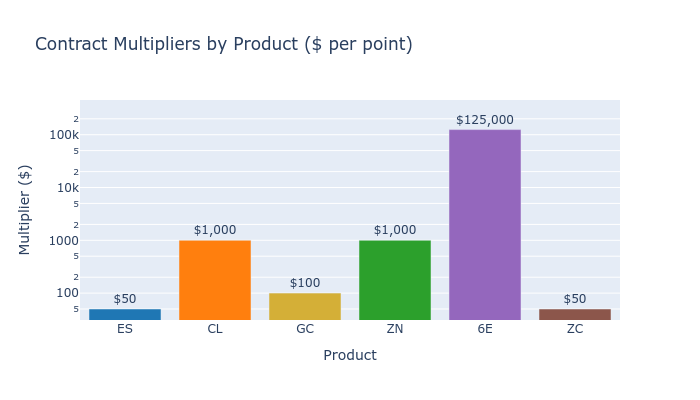

In [9]:
# Visualize multiplier range across products
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=[DEMO_SPECS[p].symbol for p in PRODUCTS],
        y=[DEMO_SPECS[p].multiplier for p in PRODUCTS],
        text=[f"${DEMO_SPECS[p].multiplier:,.0f}" for p in PRODUCTS],
        textposition="outside",
        marker_color=["#1f77b4", "#ff7f0e", "#d4af37", "#2ca02c", "#9467bd", "#8c564b"],
    )
)
fig.update_layout(
    title="Contract Multipliers by Product ($ per point)",
    xaxis_title="Product",
    yaxis_title="Multiplier ($)",
    yaxis_type="log",
    height=400,
)
fig.show()

## 3. Prepare Data for DataFeed

The ml4t-backtest `DataFeed` requires: `timestamp` (Datetime), `symbol`,
`open`, `high`, `low`, `close`, `volume`. We rename `session_date` → `timestamp`
and `product` → `symbol`.

In [10]:
prices_df = (
    cme_data.with_columns(
        pl.col("session_date").cast(pl.Datetime).alias("timestamp"),
        pl.col("product").alias("symbol"),
    )
    # Backtest fills ride the roll-adjusted series; map adj_* → the bare OHLC
    # names the DataFeed expects.
    .select(
        "timestamp",
        "symbol",
        pl.col("adj_open").alias("open"),
        pl.col("adj_high").alias("high"),
        pl.col("adj_low").alias("low"),
        pl.col("adj_close").alias("close"),
        "volume",
    )
    .sort(["timestamp", "symbol"])
)

print(f"DataFeed prices: {prices_df.shape}")
print(f"Schema: {dict(prices_df.schema)}")

DataFeed prices: (9251, 7)
Schema: {'timestamp': Datetime(time_unit='us', time_zone=None), 'symbol': String, 'open': Float64, 'high': Float64, 'low': Float64, 'close': Float64, 'volume': UInt64}


Sample DataFeed bar (first timestamp, all assets):

In [11]:
first_ts = prices_df["timestamp"][0]
prices_df.filter(pl.col("timestamp") == first_ts)

timestamp,symbol,open,high,low,close,volume
datetime[μs],str,f64,f64,f64,f64,u64
2018-01-02 00:00:00,"""6E""",1.402626,1.410179,1.401057,1.407274,188647
2018-01-02 00:00:00,"""CL""",64.809484,65.390831,64.701827,64.9925,418784
2018-01-02 00:00:00,"""ES""",2571.233563,2591.176782,2570.512724,2589.254544,964658
2018-01-02 00:00:00,"""GC""",1761.90507,1782.287179,1760.960204,1780.532428,255702
2018-01-02 00:00:00,"""ZC""",412.912543,416.14531,412.030879,415.263647,124667
2018-01-02 00:00:00,"""ZN""",123.932095,123.947714,123.479161,123.635346,1021004


## 4. Momentum Signal

We compute a 63-day trailing return for each product. This signal drives
cross-sectional ranking in the strategy.

In [12]:
# Compute trailing momentum per product
momentum_df = prices_df.sort(["symbol", "timestamp"]).with_columns(
    (pl.col("close") / pl.col("close").shift(LOOKBACK).over("symbol") - 1).alias("momentum")
)

# Create signals DataFrame for DataFeed (timestamp, asset, signal_columns)
signals_df = momentum_df.select(["timestamp", "symbol", "momentum"])

valid_count = signals_df.filter(pl.col("momentum").is_not_null()).shape[0]
print(f"Signal rows: {len(signals_df):,} ({valid_count:,} with valid momentum)")

Signal rows: 9,251 (8,873 with valid momentum)


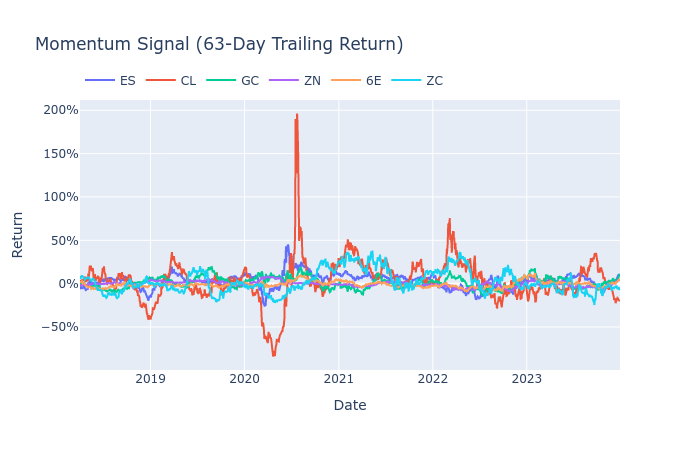

In [13]:
# Visualize momentum by product over time
fig = go.Figure()
for product in PRODUCTS:
    prod_data = momentum_df.filter((pl.col("symbol") == product) & pl.col("momentum").is_not_null())
    fig.add_trace(
        go.Scatter(
            x=prod_data["timestamp"].to_list(),
            y=prod_data["momentum"].to_list(),
            name=product,
            mode="lines",
        )
    )

fig.update_layout(
    title=f"Momentum Signal ({LOOKBACK}-Day Trailing Return)",
    xaxis_title="Date",
    yaxis_title="Return",
    yaxis_tickformat=".0%",
    height=450,
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)
fig.show()

## 5. Futures Momentum Strategy

Cross-sectional momentum ranks products by recent performance. We go **long**
the top performers and **short** the bottom performers. This long-short
structure is natural for futures:

- **No borrowing cost**: Short futures require margin, not a stock loan
- **Symmetric P&L**: Long and short have identical cost structure
- **CTA standard**: Most managed futures (CTA) funds use this approach

### Position Sizing for Futures

Each position targets equal notional exposure:

$$\text{contracts} = \left\lfloor \frac{\text{allocation}}{\text{price} \times \text{multiplier}} \right\rfloor$$

This ensures that a $250K allocation buys 1 ES contract ($250K notional)
or 3 CL contracts ($75K × 3 ≈ $225K notional).

In [14]:
class FuturesMomentumStrategy(Strategy):
    """Cross-sectional momentum on futures with proper contract sizing.

    Rebalances every N bars: long top performers, short bottom performers.
    Position sizing uses notional value (price x multiplier) to ensure
    equal dollar exposure across products with different contract sizes.
    """

    def __init__(
        self,
        contract_specs: dict[str, ContractSpec],
        long_n: int = 2,
        short_n: int = 2,
        rebalance_every: int = 21,
    ):
        self.specs = contract_specs
        self.long_n = long_n
        self.short_n = short_n
        self.rebalance_every = rebalance_every
        self.bar_count = 0

    def on_data(self, timestamp, data, context, broker):
        self.bar_count += 1
        if self.bar_count % self.rebalance_every != 0:
            return

        # 1. Collect momentum signals for all assets on this bar
        mom_signals = {}
        for asset, bar in data.items():
            mom = bar.get("signals", {}).get("momentum")
            if mom is not None and not np.isnan(mom):
                mom_signals[asset] = mom

        # Need enough assets to fill long + short buckets
        if len(mom_signals) < self.long_n + self.short_n:
            return

        # 2. Rank by momentum (highest = long, lowest = short)
        ranked = sorted(mom_signals.items(), key=lambda x: x[1], reverse=True)
        target_longs = {r[0] for r in ranked[: self.long_n]}
        target_shorts = {r[0] for r in ranked[-self.short_n :]}
        target_all = target_longs | target_shorts

        # 3. Close positions no longer in target or with wrong direction
        for asset in list(broker.positions.keys()):
            pos = broker.get_position(asset)
            if pos is None:
                continue
            if asset not in target_all:
                broker.close_position(asset)
            elif asset in target_longs and pos.quantity < 0:
                broker.close_position(asset)  # Was short, now long
            elif asset in target_shorts and pos.quantity > 0:
                broker.close_position(asset)  # Was long, now short

        # 4. Size: equal notional allocation per position
        equity = broker.get_account_value()
        n_positions = self.long_n + self.short_n
        alloc = equity / n_positions

        # 5. Open new positions (skip assets already correctly positioned)
        for asset in target_longs:
            pos = broker.get_position(asset)
            if pos is not None and pos.quantity > 0:
                continue  # Already long
            price = data[asset]["close"]
            mult = self.specs[asset].multiplier
            qty = max(1, int(alloc / (price * mult)))
            broker.submit_order(asset, qty, OrderSide.BUY)

        for asset in target_shorts:
            pos = broker.get_position(asset)
            if pos is not None and pos.quantity < 0:
                continue  # Already short
            price = data[asset]["close"]
            mult = self.specs[asset].multiplier
            qty = max(1, int(alloc / (price * mult)))
            broker.submit_order(asset, qty, OrderSide.SELL)

## 6. Configure and Run Backtest

The `BacktestConfig` controls all behavioral settings. For futures:

- `CommissionType.PER_CONTRACT` with `commission_per_share=2.00` models
  **$2 per contract** (flat fee per contract, like Interactive Brokers)
- `allow_short_selling=True` enables short positions
- `allow_leverage=True` enables margin-based sizing (futures are leveraged)

`ContractSpec` is **product metadata** (static per instrument), not a behavioral
knob. Pass `contract_specs=` to the `Engine` constructor — the Engine threads
it through to the `Broker` automatically.

In [15]:
config = BacktestConfig(
    initial_cash=INITIAL_CASH,
    execution_mode=ExecutionMode.NEXT_BAR,
    # Per-contract commission ($2 per contract, like IB futures)
    commission_type=CommissionType.PER_CONTRACT,
    commission_per_share=2.00,
    commission_minimum=2.00,
    # Slippage: 5 bps of price
    slippage_type=SlippageType.PERCENTAGE,
    slippage_rate=0.0005,
    # Futures require short selling and leverage
    allow_short_selling=True,
    allow_leverage=True,
)

# Create DataFeed with prices and momentum signals
feed = DataFeed(prices_df=prices_df, signals_df=signals_df)

# Create strategy
strategy = FuturesMomentumStrategy(
    contract_specs=DEMO_SPECS,
    long_n=LONG_N,
    short_n=SHORT_N,
    rebalance_every=REBALANCE_EVERY,
)

# Create engine with contract specs — Engine threads them to the Broker
engine = Engine(feed=feed, strategy=strategy, config=config, contract_specs=DEMO_SPECS)

# Run backtest
result = engine.run()

**Futures momentum backtest — with contract specs.**

In [16]:
pl.DataFrame(
    {
        "metric": [
            "Initial capital ($)",
            "Final value ($)",
            "Total return (%)",
            "Sharpe ratio",
            "Max drawdown (%)",
            "Total trades",
            "Win rate (%)",
        ],
        "value": [
            float(INITIAL_CASH),
            float(result.metrics["final_value"]),
            float(result.metrics["total_return_pct"]),
            float(result.metrics["sharpe"]),
            float(result.metrics["max_drawdown_pct"]),
            float(result.metrics["num_trades"]),
            float(result.metrics["win_rate"] * 100),
        ],
    }
)

metric,value
str,f64
"""Initial capital ($)""",1e6
"""Final value ($)""",1.0625e6
"""Total return (%)""",6.245356
"""Sharpe ratio""",0.144655
"""Max drawdown (%)""",28.989704
"""Total trades""",99.0
"""Win rate (%)""",51.515152


The strategy produces modest returns with a low Sharpe ratio and substantial
drawdown relative to the return — typical of a simple cross-sectional
momentum rule on a small (6-product) universe without risk management.
The high drawdown-to-return ratio underscores why CTA funds combine momentum
with volatility targeting and portfolio-level risk limits (covered in Ch17–19).

## 7. Analyze Trades

Verify that the broker applied the correct multiplier per product.
Each trade's P&L should reflect the contract multiplier.

In [17]:
trades_df = result.to_trades_dataframe()
closed_trades = trades_df.filter(pl.col("status") == "closed")

print(f"Total trades: {len(trades_df)} ({len(closed_trades)} closed)")

Total trades: 103 (99 closed)


Sample of closed trades with multiplier-correct P&L and cost decomposition:

In [18]:
closed_trades.select(
    [
        "symbol",
        "direction",
        "quantity",
        "entry_price",
        "exit_price",
        "pnl",
        "pnl_percent",
        "gross_pnl",
        "cost_drag",
        "bars_held",
    ]
).head(10)

symbol,direction,quantity,entry_price,exit_price,pnl,pnl_percent,gross_pnl,cost_drag,bars_held
str,str,f64,f64,f64,f64,f64,f64,f64,i32
"""ES""","""short""",-1.0,2538.186649,2585.611866,-2375.260876,-0.018685,-2371.260876,0.001041,21
"""ZC""","""long""",11.0,450.716899,394.684893,-30861.603161,-0.124318,-30817.603161,0.001115,42
"""GC""","""short""",-1.0,1738.622597,1673.609938,6497.265899,0.037393,6501.265899,0.001004,21
"""6E""","""short""",-1.0,1.397711,1.33958,7262.373973,0.04159,7266.373973,0.001002,63
"""CL""","""long""",3.0,73.898798,74.146343,730.636613,0.00335,742.636613,0.001056,126
"""ES""","""long""",1.0,2595.063423,2625.563164,1520.987042,0.011753,1524.987042,0.001037,84
"""ZC""","""short""",-12.0,394.684893,386.761854,4705.823708,0.020074,4753.823708,0.001193,84
"""GC""","""short""",-1.0,1629.658601,1634.616502,-499.790181,-0.003042,-495.790181,0.001026,63
"""ZC""","""long""",12.0,386.761854,380.017159,-4094.8166,-0.017439,-4046.8166,0.001198,42


Trade summary by product (P&L, win rate):

In [19]:
trade_summary = (
    closed_trades.group_by("symbol")
    .agg(
        pl.len().alias("trades"),
        pl.col("pnl").sum().alias("total_pnl"),
        pl.col("pnl").mean().alias("avg_pnl"),
        (pl.col("pnl") > 0).mean().alias("win_rate"),
    )
    .sort("total_pnl", descending=True)
)
trade_summary

symbol,trades,total_pnl,avg_pnl,win_rate
str,u32,f64,f64,f64
"""GC""",18,45225.732703,2512.540706,0.722222
"""6E""",9,34893.776011,3877.086223,0.555556
"""CL""",19,9651.690132,507.983691,0.473684
"""ZC""",18,2242.878896,124.604383,0.388889
"""ZN""",19,1562.139411,82.217864,0.526316
"""ES""",16,-66593.485413,-4162.092838,0.4375


P&L concentration across products is pronounced: a few products drive most of
the profit, while others (notably the highly leveraged equity index) create
large losses. This is expected with cross-sectional momentum on a small
universe and motivates the full 30-product scaling in Section 10.

## 8. Without Multipliers — The Error

Running the identical strategy **without** `ContractSpec` (multiplier = 1.0
for all products) shows how P&L is systematically misstated. The strategy
sizes positions identically in both runs — only the broker's P&L
calculation differs.

In [20]:
# Run same strategy WITHOUT contract specs on broker (multiplier defaults to 1.0)
feed_nomult = DataFeed(prices_df=prices_df, signals_df=signals_df)
strategy_nomult = FuturesMomentumStrategy(
    contract_specs=DEMO_SPECS,  # Strategy still sizes correctly
    long_n=LONG_N,
    short_n=SHORT_N,
    rebalance_every=REBALANCE_EVERY,
)
engine_nomult = Engine(feed=feed_nomult, strategy=strategy_nomult, config=config)
# NO contract_specs → broker uses multiplier=1.0 for all products
result_nomult = engine_nomult.run()

pl.DataFrame(
    {
        "metric": ["Final value ($)", "Total return (%)", "Max drawdown (%)"],
        "with_specs": [
            result.metrics["final_value"],
            result.metrics["total_return_pct"],
            result.metrics["max_drawdown_pct"],
        ],
        "without_multipliers": [
            result_nomult.metrics["final_value"],
            result_nomult.metrics["total_return_pct"],
            result_nomult.metrics["max_drawdown_pct"],
        ],
    }
)

metric,with_specs,without_multipliers
str,f64,f64
"""Final value ($)""",1.0625e6,998475.68448
"""Total return (%)""",6.245356,-0.152432
"""Max drawdown (%)""",28.989704,0.518822


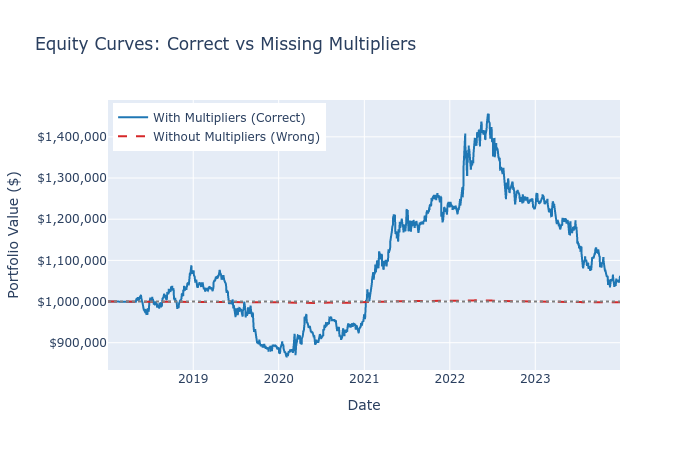

In [21]:
# Overlay equity curves
fig = go.Figure()
ec_with = result.equity
ec_without = result_nomult.equity

fig.add_trace(
    go.Scatter(
        x=ec_with.timestamps,
        y=ec_with.values,
        name="With Multipliers (Correct)",
        line=dict(color="#1f77b4", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=ec_without.timestamps,
        y=ec_without.values,
        name="Without Multipliers (Wrong)",
        line=dict(color="#d62728", width=2, dash="dash"),
    )
)
fig.add_hline(y=INITIAL_CASH, line_dash="dot", line_color="gray")

fig.update_layout(
    title="Equity Curves: Correct vs Missing Multipliers",
    xaxis_title="Date",
    yaxis_title="Portfolio Value ($)",
    yaxis_tickformat="$,.0f",
    height=450,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
)
fig.show()

The equity curves diverge dramatically. Without multipliers, the backtest
reports near-zero P&L because it treats each price point as $1 instead of
$50–$125,000 per contract.

## 9. Sector Attribution

Futures provide natural diversification across uncorrelated asset classes.
We map each product to its sector and compute P&L contribution.

In [22]:
SECTOR_MAP = {
    "ES": "Equity Index",
    "CL": "Energy",
    "GC": "Metals",
    "ZN": "Rates",
    "6E": "FX",
    "ZC": "Agriculture",
}

sector_pnl = (
    closed_trades.with_columns(
        pl.col("symbol").replace_strict(SECTOR_MAP, default="Other").alias("sector")
    )
    .group_by("sector")
    .agg(
        pl.col("pnl").sum().alias("total_pnl"),
        pl.len().alias("trades"),
        (pl.col("pnl") > 0).mean().alias("win_rate"),
    )
    .sort("total_pnl", descending=True)
)
sector_pnl

sector,total_pnl,trades,win_rate
str,f64,u32,f64
"""Metals""",45225.732703,18,0.722222
"""FX""",34893.776011,9,0.555556
"""Energy""",9651.690132,19,0.473684
"""Agriculture""",2242.878896,18,0.388889
"""Rates""",1562.139411,19,0.526316
"""Equity Index""",-66593.485413,16,0.4375


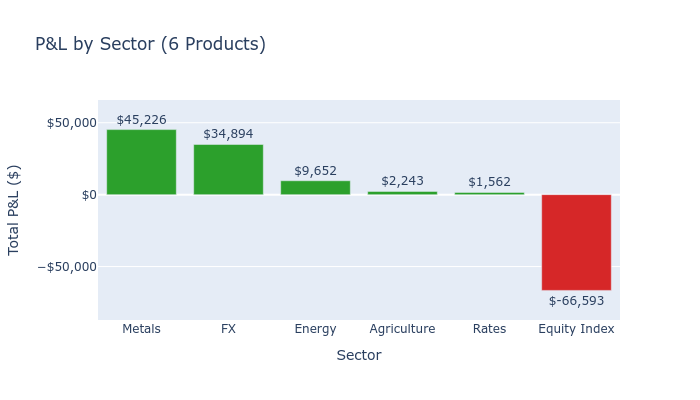

In [23]:
# Visualize sector P&L
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=sector_pnl["sector"].to_list(),
        y=sector_pnl["total_pnl"].to_list(),
        marker_color=["#2ca02c" if p > 0 else "#d62728" for p in sector_pnl["total_pnl"].to_list()],
        text=[f"${p:,.0f}" for p in sector_pnl["total_pnl"].to_list()],
        textposition="outside",
    )
)
fig.update_layout(
    title="P&L by Sector (6 Products)",
    xaxis_title="Sector",
    yaxis_title="Total P&L ($)",
    yaxis_tickformat="$,.0f",
    height=400,
)
fig.show()

With only one product per sector, sector and product attribution are
identical. The key insight is that sectors contribute asymmetrically: metals
and FX drove profits while equity index was a significant drag. CTA
strategies mitigate single-sector risk by trading across many products per
sector — the 30-product run below addresses this.

## 10. Full 30-Product Universe

Scale from 6 demo products to the full CME universe. We load contract
specifications from `futures_specs.yaml` and derive point-value multipliers
from tick values: `multiplier = tick_value / tick_size`.

In [24]:
SPECS_PATH = REPO_ROOT / "data" / "futures" / "market" / "futures_specs.yaml"


def load_contract_specs_from_yaml(yaml_path: Path) -> dict[str, ContractSpec]:
    """Load contract specs from YAML, computing P&L multiplier from tick values.

    The YAML stores tick_value and tick_size per product. The P&L multiplier
    (point value) is derived as: multiplier = tick_value / tick_size.
    """
    with open(yaml_path) as f:
        raw = yaml.safe_load(f)

    specs = {}
    for symbol, info in raw["products"].items():
        multiplier = info["tick_value"] / info["tick_size"]
        specs[symbol] = ContractSpec(
            symbol=symbol,
            asset_class=AssetClass.FUTURE,
            multiplier=multiplier,
            tick_size=info["tick_size"],
        )
    return specs


FULL_SPECS = load_contract_specs_from_yaml(SPECS_PATH)
print(f"Loaded {len(FULL_SPECS)} product specifications from YAML")

Loaded 36 product specifications from YAML


Cross-check: the YAML-derived multipliers for the six demo products match
the hand-coded `DEMO_SPECS` we used above.

In [25]:
verify_rows = []
for product in PRODUCTS:
    demo_mult = DEMO_SPECS[product].multiplier
    yaml_mult = FULL_SPECS[product].multiplier
    verify_rows.append(
        {
            "product": product,
            "demo_multiplier": float(demo_mult),
            "yaml_multiplier": float(yaml_mult),
            "match": abs(demo_mult - yaml_mult) < 0.01,
        }
    )
pl.DataFrame(verify_rows)

product,demo_multiplier,yaml_multiplier,match
str,f64,f64,bool
"""ES""",50.0,50.0,true
"""CL""",1000.0,1000.0,true
"""GC""",100.0,100.0,true
"""ZN""",1000.0,1000.0,true
"""6E""",125000.0,125000.0,true
"""ZC""",50.0,50.0,true


In [26]:
if RUN_FULL_UNIVERSE:
    cme_all = load_cme_futures(tenors=[0], start_date=START_DATE, end_date=END_DATE)
    available_products = set(cme_all["product"].unique().to_list())
    universe = sorted(available_products & set(FULL_SPECS.keys()))

    print(f"\nAvailable in data: {len(available_products)} products")
    print(f"Have specs for:    {len(FULL_SPECS)} products")
    print(f"Universe:          {len(universe)} products")
    print(f"Products: {universe}")

    cme_all = cme_all.filter(pl.col("product").is_in(universe))

    # Prepare full-universe data
    prices_full = (
        cme_all.with_columns(
            pl.col("session_date").cast(pl.Datetime).alias("timestamp"),
            pl.col("product").alias("symbol"),
        )
        # Backtest fills ride the roll-adjusted series (adj_* → bare OHLC).
        .select(
            "timestamp",
            "symbol",
            pl.col("adj_open").alias("open"),
            pl.col("adj_high").alias("high"),
            pl.col("adj_low").alias("low"),
            pl.col("adj_close").alias("close"),
            "volume",
        )
        .sort(["timestamp", "symbol"])
    )

    signals_full = (
        prices_full.sort(["symbol", "timestamp"])
        .with_columns(
            (pl.col("close") / pl.col("close").shift(LOOKBACK).over("symbol") - 1).alias("momentum")
        )
        .select(["timestamp", "symbol", "momentum"])
    )

    universe_specs = {p: FULL_SPECS[p] for p in universe}

    feed_full = DataFeed(prices_df=prices_full, signals_df=signals_full)
    strategy_full = FuturesMomentumStrategy(
        contract_specs=universe_specs,
        long_n=6,
        short_n=6,
        rebalance_every=REBALANCE_EVERY,
    )
    engine_full = Engine(
        feed=feed_full, strategy=strategy_full, config=config, contract_specs=universe_specs
    )

    result_full = engine_full.run()


Available in data: 30 products
Have specs for:    36 products
Universe:          30 products
Products: ['6A', '6B', '6C', '6E', '6J', '6S', 'CL', 'ES', 'GC', 'GF', 'HE', 'HG', 'HO', 'LE', 'NG', 'NQ', 'PL', 'RB', 'RTY', 'SI', 'YM', 'ZB', 'ZC', 'ZF', 'ZL', 'ZM', 'ZN', 'ZS', 'ZT', 'ZW']


Six-product baseline vs full CME universe — same momentum rule, same costs:

In [27]:
if RUN_FULL_UNIVERSE:
    comparison = pl.DataFrame(
        {
            "metric": [
                "Products",
                "Final value ($)",
                "Sharpe ratio",
                "Max drawdown (%)",
                "Total trades",
            ],
            "six_products": [
                float(6),
                float(result.metrics["final_value"]),
                float(result.metrics["sharpe"]),
                float(result.metrics["max_drawdown_pct"]),
                float(result.metrics["num_trades"]),
            ],
            "full_universe": [
                float(len(universe)),
                float(result_full.metrics["final_value"]),
                float(result_full.metrics["sharpe"]),
                float(result_full.metrics["max_drawdown_pct"]),
                float(result_full.metrics["num_trades"]),
            ],
        }
    )
else:
    comparison = pl.DataFrame({"note": ["Skipped full-universe scaling (RUN_FULL_UNIVERSE=False)"]})
comparison

metric,six_products,full_universe
str,f64,f64
"""Products""",6.0,30.0
"""Final value ($)""",1.0625e6,954467.914581
"""Sharpe ratio""",0.144655,0.079925
"""Max drawdown (%)""",28.989704,50.285829
"""Total trades""",99.0,380.0


Scaling from 6 to 30 products increases the trade count and produces
a higher drawdown but a lower Sharpe. This illustrates that naively adding
products does not automatically improve risk-adjusted returns — position
sizing, volatility targeting, and sector-level risk allocation are needed to
turn a larger universe into genuine diversification (Ch17–19).

## 11. Cost Analysis — Per-Contract vs Percentage

Percentage-based costs systematically misprice futures because notional
values vary 100×+ across products. A flat $2/contract is more realistic
and matches institutional pricing (e.g., Interactive Brokers).

Notional value per contract by product, and a flat \$2 commission expressed as
a percentage of notional. The cost percentage varies materially across
products because their multipliers and prices differ; the printed min/max
below quantifies the spread for the six demo contracts.

In [28]:
cost_rows = []
for product in PRODUCTS:
    spec = DEMO_SPECS[product]
    price = float(cme_data.filter(pl.col("product") == product)["raw_close"][-1])
    notional = price * spec.multiplier
    cost_rows.append(
        {
            "product": product,
            "price": price,
            "multiplier": float(spec.multiplier),
            "notional_usd": notional,
            "two_dollar_pct_of_notional": 2.0 / notional * 100,
        }
    )
cost_table = pl.DataFrame(cost_rows)
_cost_min = cost_table["two_dollar_pct_of_notional"].min()
_cost_max = cost_table["two_dollar_pct_of_notional"].max()
print(
    f"$2/contract cost as % of notional: min {_cost_min:.4f}%, "
    f"max {_cost_max:.4f}% (ratio {_cost_max / _cost_min:.1f}×)"
)
cost_table

$2/contract cost as % of notional: min 0.0008%, max 0.0085% (ratio 10.2×)


product,price,multiplier,notional_usd,two_dollar_pct_of_notional
str,f64,f64,f64,f64
"""ES""",4812.75,50.0,240637.5,0.000831
"""CL""",71.33,1000.0,71330.0,0.002804
"""GC""",2071.8,100.0,207180.0,0.000965
"""ZN""",112.6875,1000.0,112687.5,0.001775
"""6E""",1.10705,125000.0,138381.25,0.001445
"""ZC""",470.75,50.0,23537.5,0.008497


A flat \$2/contract ranges from a tiny fraction of notional on large-multiplier
contracts (ES, 6E) to a more meaningful share on small-notional contracts
(ZC, ZN). Percentage-based costs (e.g., 10 bps) overcharge small-notional
products and undercharge large-notional ones — which is why per-contract
pricing is the institutional norm for futures.

## Key Takeaways

1. **Always use `ContractSpec`** for futures backtesting. Without it, P&L
   is understated by 20×–1000× depending on the contract.

2. **Position sizing uses notional value**: $q = \lfloor \text{alloc} / (\text{price} \times \text{multiplier}) \rfloor$.
   This ensures equal dollar exposure across products with different multipliers.

3. **Long-short is natural** for futures — no borrowing cost, symmetric P&L,
   and margin-efficient (positions partially offset).

4. **Per-contract costs** ($2/contract) are more realistic than percentage-based
   costs for futures. Notional values vary 100×+, so percentage costs distort.

5. **Sector attribution exposes concentration**, not diversification benefits
   by itself. In this 6-product run, P&L was concentrated in a few sectors
   (metals and FX positive, equity index negative). §10 reports the
   6→30-product scaling comparison from the `comparison` table directly;
   naively adding products without changing sizing leaves the per-sector
   concentration unchanged. Ch17–19 examine whether risk-targeted sizing
   converts a larger universe into genuine diversification.

## Next Steps

- **CME case study**: `case_studies/cme_futures/strategy/backtest.py`
- **Ch17**: Portfolio construction with margin-based position sizing
- **Ch18**: Transaction cost decomposition for futures

## Cross-References

- **Ch2 NB 05**: Session boundary aggregation (4 PM CT → daily bars)
- **Ch2 NB 06**: Continuous contract construction (Panama/ratio adjustment)
- `ml4t.backtest.types.ContractSpec`: Full API reference